# CSCI 4360 Final Project

### Name: Shivali Pathania

**Due Date**: go to eLC, click "Tools"->"Assignments" to check for the deadline. Please note that the final project **cannot be submitted late**. The regular late policy does not apply to the final project.

**Submission**: submit this completed Jupyter Notebook file (.ipynb extension) to eLC. Please be sure to **keep all the output cells**, so that the TA can see your outputs directly without running your notebook.

This assignment is to be completed individually. You may use generative AI technology to help you complete this assignment, but you are ultimately responsible for the correctness of your submission.

Tip: if you are running on Colab, be sure to check that you are actually using the GPU. Click the top menu item **"Runtime"->"Change runtime type"**, and make sure **"T4 GPU"** is selected.

### Instructions

This final project focuses on time series forecasting using various models.

#### Dataset
Go to https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption to download and extract the "household_power_consumption.txt" data file.

The dataset does contain some missing values. Please deal with them appropriately.

The forecasting target is "Global_active_power". You can choose to do univariate time series analysis by only focusing on this column. You are also free to use the other columns as additional inputs to your models.

Please chronologically split the data into first 70% for training, next 15% for validation, and the last 15% for testing.

You are to use the most recent 120 minutes of historical data to make forecasts for the next 15 steps. Note that this means you need to make 15 forecast values from t+1 to t+15, not just a single forecast value for t+15.

#### Models

Please test and compare the following models. You must use PyTorch for the neural network models. You are free to tune hyperparameters and design appropriate neural network architectures.

1. A naive forecasting model that simply copies the most recent historical value for forecasting.
2. ARIMA
3. RNN
4. LSTM
5. GRU
6. Conv1d

Please be sure to include a plot that compares the forecasting performance of all the models and a summary of your findings.

In [ ]:


import pandas as pd
import numpy as np
!pip install ucimlrepo -q
from ucimlrepo import fetch_ucirepo

# Fetch dataset
dataset = fetch_ucirepo(id=235)
df = dataset.data.original
df.head()

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [ ]:
df.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.0


In [ ]:
!pip install statsmodels pmdarima -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Statsmodels for ARIMA
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Sklearn for scaling
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"PyTorch version: {torch.__version__}")

Using device: cuda
GPU: Tesla T4
PyTorch version: 2.10.0+cu128


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## DATA LOADING

In [ ]:
import pandas as pd
import numpy as np

# 1. Convert all numerical columns to floats (replaces '?' with NaN automatically)
cols_to_fix = ['Global_active_power', 'Global_reactive_power', 'Voltage',
               'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Create the Datetime Index (CRITICAL for chronological splitting later)
# If your Date/Time columns are still strings, combine them now
if 'Date' in df.columns and 'Time' in df.columns:
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    df.set_index('datetime', inplace=True)
    df.drop(['Date', 'Time'], axis=1, inplace=True)

# 3. Apply Linear Interpolation (The best logic for time series)
# 'both' ensures that even if the first rows are missing, they get filled
df.interpolate(method='linear', limit_direction='both', inplace=True)

# 4. Final verification
print("Missing values after interpolation:")
print(df.isnull().sum())
print(f"\nNew Date range: {df.index.min()} to {df.index.max()}")

Missing values after interpolation:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

New Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


In [ ]:
df.head(10)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
2006-12-16 17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0
2006-12-16 17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0
2006-12-16 17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0
2006-12-16 17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0


In [ ]:
# ── Quick EDA ─────────────────────────────────────────────────────────────────
print(df.describe())



       Global_active_power  Global_reactive_power       Voltage  \
count         2.075259e+06           2.075259e+06  2.075259e+06   
mean          1.090280e+00           1.236492e-01  2.408328e+02   
std           1.052628e+00           1.124194e-01  3.237763e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.100000e-01           4.800000e-02  2.389900e+02   
50%           6.140000e-01           1.000000e-01  2.410000e+02   
75%           1.528000e+00           1.940000e-01  2.428700e+02   
max           1.112200e+01           1.390000e+00  2.541500e+02   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count      2.075259e+06    2.075259e+06    2.075259e+06    2.075259e+06  
mean       4.621481e+00    1.109485e+00    1.289229e+00    6.442386e+00  
std        4.424361e+00    6.115843e+00    5.786613e+00    8.415860e+00  
min        2.000000e-01    0.000000e+00    0.000000e+00    0.000000e+00  
25%        1.400000e+00   

In [ ]:
# ── Chronological 70 / 15 / 15 split ─────────────────────────────────────────
N = len(df)
train_end = int(N * 0.70)
val_end   = int(N * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print(f"Total samples : {N:,}")
print(f"Train  : {len(train_df):,}  ({len(train_df)/N*100:.1f}%)  "
      f"{train_df.index[0]} → {train_df.index[-1]}")
print(f"Val    : {len(val_df):,}  ({len(val_df)/N*100:.1f}%)  "
      f"{val_df.index[0]} → {val_df.index[-1]}")
print(f"Test   : {len(test_df):,}  ({len(test_df)/N*100:.1f}%)  "
      f"{test_df.index[0]} → {test_df.index[-1]}")

Total samples : 2,075,259
Train  : 1,452,681  (70.0%)  2006-12-16 17:24:00 → 2009-09-20 12:44:00
Val    : 311,289  (15.0%)  2009-09-20 12:45:00 → 2010-04-24 16:53:00
Test   : 311,289  (15.0%)  2010-04-24 16:54:00 → 2010-11-26 21:02:00


                       Global_active_power  Global_reactive_power   Voltage  \
Global_active_power               1.000000               0.245047 -0.395522   
Global_reactive_power             0.245047               1.000000 -0.109030   
Voltage                          -0.395522              -0.109030  1.000000   
Global_intensity                  0.998887               0.264162 -0.407198   
Sub_metering_1                    0.483816               0.122743 -0.194100   
Sub_metering_2                    0.433892               0.139204 -0.165348   
Sub_metering_3                    0.639272               0.087743 -0.265510   

                       Global_intensity  Sub_metering_1  Sub_metering_2  \
Global_active_power            0.998887        0.483816        0.433892   
Global_reactive_power          0.264162        0.122743        0.139204   
Voltage                       -0.407198       -0.194100       -0.165348   
Global_intensity               1.000000        0.488756        0.43

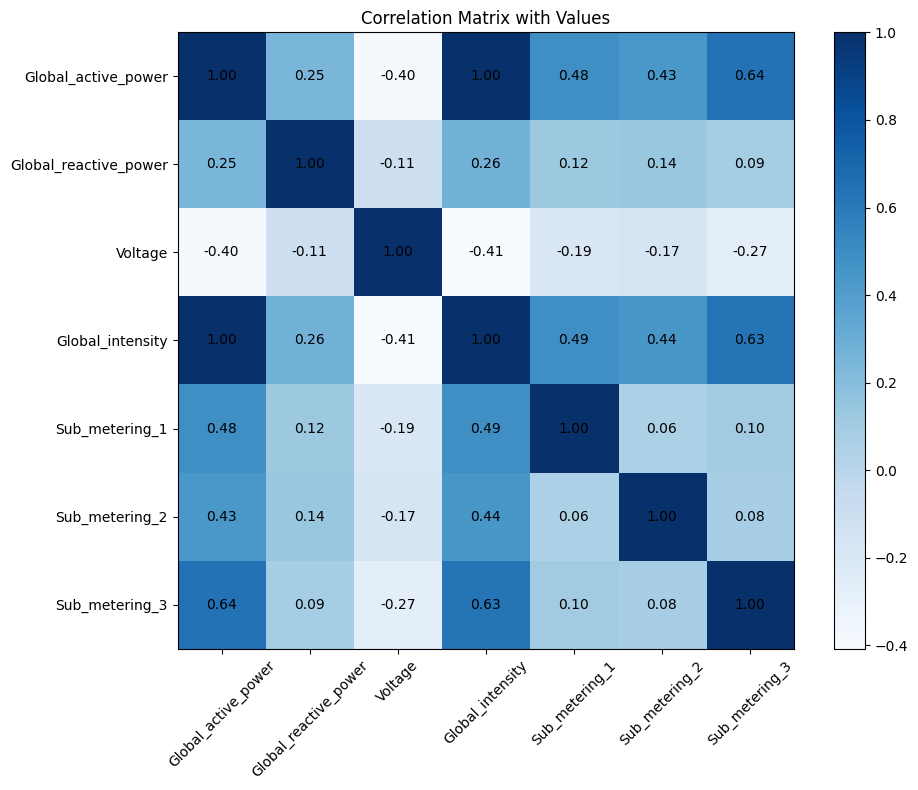

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns
numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

# Convert the selected columns to numeric, coercing '?' to NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create correlation matrix
corr_matrix = df[numeric_cols].corr()

# Print exact values
print(corr_matrix)

# Plot correlation matrix with numbers inside
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Add correlation values inside boxes
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=10
        )

plt.title("Correlation Matrix with Values")
plt.tight_layout()
plt.show()

In [ ]:
# ── Scale using training statistics only ──────────────────────────────────────
TARGET = 'Global_active_power'
FEATURES = df.columns.tolist()   # use all 7 columns as input features

scaler = MinMaxScaler()
scaler.fit(train_df[FEATURES])

train_scaled = scaler.transform(train_df[FEATURES])
val_scaled   = scaler.transform(val_df[FEATURES])
test_scaled  = scaler.transform(test_df[FEATURES])

# Index of target column
target_idx = FEATURES.index(TARGET)
print(f"Target column index: {target_idx}  ({TARGET})")

Target column index: 0  (Global_active_power)


In [ ]:
LOOKBACK  = 120   # 120 minutes of history
HORIZON   = 15    # forecast t+1 … t+15
N_FEATURES = len(FEATURES)


def make_sequences(data, lookback=LOOKBACK, horizon=HORIZON, target_idx=target_idx):
    """Return (X, y) numpy arrays.
    X : (samples, lookback, n_features)
    y : (samples, horizon)  – target column only
    """
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X_train, y_train = make_sequences(train_scaled)
X_val,   y_val   = make_sequences(val_scaled)
X_test,  y_test  = make_sequences(test_scaled)

print(f"Train  X: {X_train.shape}  y: {y_train.shape}")
print(f"Val    X: {X_val.shape}    y: {y_val.shape}")
print(f"Test   X: {X_test.shape}   y: {y_test.shape}")

Train  X: (1452547, 120, 7)  y: (1452547, 15)
Val    X: (311155, 120, 7)    y: (311155, 15)
Test   X: (311155, 120, 7)   y: (311155, 15)


In [ ]:
class PowerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


BATCH_SIZE = 256

train_loader = DataLoader(PowerDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(PowerDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(PowerDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# We need to invert the MinMaxScaler on the target column only
target_min = scaler.data_min_[target_idx]
target_max = scaler.data_max_[target_idx]

def inverse_target(arr):
    """Invert scaling for the target column."""
    return arr * (target_max - target_min) + target_min


def compute_metrics(y_true, y_pred):
    """Return RMSE and MAE on the original (unscaled) scale."""
    y_true_inv = inverse_target(y_true)
    y_pred_inv = inverse_target(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true_inv.flatten(), y_pred_inv.flatten()))
    mae  = mean_absolute_error(y_true_inv.flatten(), y_pred_inv.flatten())
    return rmse, mae


results = {}   # will hold {'model_name': (rmse, mae, y_pred_array)}

# NAIVE MODEL


In [ ]:
# Naive: repeat the last observed value (scaled) across all 15 forecast steps
naive_preds = X_test[:, -1, target_idx:target_idx+1]   # (N, 1)
naive_preds = np.repeat(naive_preds, HORIZON, axis=1)   # (N, 15)

rmse_naive, mae_naive = compute_metrics(y_test, naive_preds)
results['Naive'] = (rmse_naive, mae_naive, naive_preds)
print(f"Naive  →  RMSE: {rmse_naive:.4f}  MAE: {mae_naive:.4f}")

Naive  →  RMSE: 0.5422  MAE: 0.2612


# ARIMA Model


In [ ]:
# ARIMA Model

# Use hourly-resampled training data to find a reasonable ARIMA order faster
train_hourly = train_df[TARGET].resample('h').mean().dropna()

print("Running auto_arima to find best (p,d,q)...")

auto_model = auto_arima(
    train_hourly,
    start_p=1, max_p=3,
    start_q=0, max_q=2,
    d=None,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

order = auto_model.order
print(f"Selected ARIMA order: {order}")

Running auto_arima to find best (p,d,q)...
Selected ARIMA order: (0, 1, 2)


In [ ]:
# Evaluate ARIMA on chronological test windows
# ARIMA is fit on each 120-minute window and forecasts the next 15 steps

N_EVAL = 300
idxs = np.arange(N_EVAL)   # first 300 test windows, chronological

arima_preds = np.zeros((N_EVAL, HORIZON))

for j, i in enumerate(idxs):
    history = X_test[i, :, target_idx]   # 120 scaled Global_active_power values

    try:
        model = ARIMA(history, order=order)
        fit = model.fit()
        fc = fit.forecast(steps=HORIZON)
        arima_preds[j] = fc
    except Exception:
        arima_preds[j] = history[-1]

    if (j + 1) % 50 == 0:
        print(f"{j+1}/{N_EVAL} windows done")

rmse_arima, mae_arima = compute_metrics(y_test[idxs], arima_preds)

results['ARIMA'] = (rmse_arima, mae_arima, arima_preds)

print(f"ARIMA → RMSE: {rmse_arima:.4f}, MAE: {mae_arima:.4f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


50/300 windows done


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


100/300 windows done
150/300 windows done
200/300 windows done


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


250/300 windows done
300/300 windows done
ARIMA → RMSE: 0.8721, MAE: 0.5880


## RNN


In [ ]:
def train_model(model, train_loader, val_loader, n_epochs=30, lr=1e-3, patience=5):
    """Generic training loop with early stopping."""
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0
    train_losses, val_losses = [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        running = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running += loss.item() * xb.size(0)

        train_loss = running / len(train_loader.dataset)

        model.eval()
        running = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                running += loss.item() * xb.size(0)

        val_loss = running / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {epoch}")
                break

        print(f"Epoch {epoch}/{n_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses


@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds = []

    for xb, _ in loader:
        xb = xb.to(device)
        pred = model(xb)
        preds.append(pred.cpu().numpy())

    return np.concatenate(preds, axis=0)


print("Training utilities defined.")

Training utilities defined.


In [ ]:
# RNN Model

class RNNForecast(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, horizon=15):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, hidden = self.rnn(x)
        last_hidden = out[:, -1, :]
        forecast = self.fc(last_hidden)
        return forecast


rnn_model = RNNForecast(
    input_size=N_FEATURES,
    hidden_size=64,
    num_layers=1,
    horizon=HORIZON
)

rnn_model, rnn_train_losses, rnn_val_losses = train_model(
    rnn_model,
    train_loader,
    val_loader,
    n_epochs=30,
    lr=1e-3,
    patience=5
)

rnn_preds = predict(rnn_model, test_loader)

rmse_rnn, mae_rnn = compute_metrics(y_test, rnn_preds)

results["RNN"] = (rmse_rnn, mae_rnn, rnn_preds)

print(f"RNN → RMSE: {rmse_rnn:.4f}  MAE: {mae_rnn:.4f}")

Epoch 1/30 | Train Loss: 0.002779 | Val Loss: 0.002485
Epoch 2/30 | Train Loss: 0.002700 | Val Loss: 0.002497
Epoch 3/30 | Train Loss: 0.002693 | Val Loss: 0.002491
Epoch 4/30 | Train Loss: 0.002684 | Val Loss: 0.002515
Epoch 5/30 | Train Loss: 0.002660 | Val Loss: 0.002448
Epoch 6/30 | Train Loss: 0.002650 | Val Loss: 0.002438
Epoch 7/30 | Train Loss: 0.002635 | Val Loss: 0.002436
Epoch 8/30 | Train Loss: 0.002599 | Val Loss: 0.002353
Epoch 9/30 | Train Loss: 0.002541 | Val Loss: 0.002356
Epoch 10/30 | Train Loss: 0.002505 | Val Loss: 0.002305
Epoch 11/30 | Train Loss: 0.002490 | Val Loss: 0.002292
Epoch 12/30 | Train Loss: 0.002482 | Val Loss: 0.002289
Epoch 13/30 | Train Loss: 0.002473 | Val Loss: 0.002271
Epoch 14/30 | Train Loss: 0.002467 | Val Loss: 0.002329
Epoch 15/30 | Train Loss: 0.002461 | Val Loss: 0.002223
Epoch 16/30 | Train Loss: 0.002435 | Val Loss: 0.002245
Epoch 17/30 | Train Loss: 0.002424 | Val Loss: 0.002227
Epoch 18/30 | Train Loss: 0.002420 | Val Loss: 0.002282
E

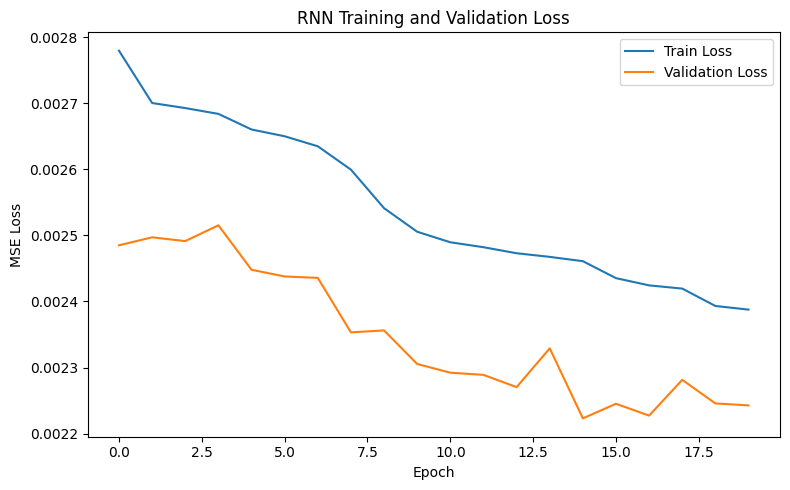

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(rnn_train_losses, label="Train Loss")
plt.plot(rnn_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("RNN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden_size=128, num_layers=2,
                 horizon=HORIZON, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


print("Training LSTM…")
lstm_model = LSTMModel(n_features=N_FEATURES)
lstm_model, lstm_tr, lstm_vl = train_model(
    lstm_model, train_loader, val_loader, n_epochs=9, lr=1e-3, patience=6)

lstm_preds = predict(lstm_model, test_loader)
rmse_lstm, mae_lstm = compute_metrics(y_test, lstm_preds)
results['LSTM'] = (rmse_lstm, mae_lstm, lstm_preds)
print(f"\nLSTM  →  RMSE: {rmse_lstm:.4f}  MAE: {mae_lstm:.4f}")

Training LSTM…
Epoch 1/9 | Train Loss: 0.002970 | Val Loss: 0.002472
Epoch 2/9 | Train Loss: 0.002809 | Val Loss: 0.002462
Epoch 3/9 | Train Loss: 0.002766 | Val Loss: 0.002406
Epoch 4/9 | Train Loss: 0.002740 | Val Loss: 0.002425
Epoch 5/9 | Train Loss: 0.002731 | Val Loss: 0.002408
Epoch 6/9 | Train Loss: 0.002716 | Val Loss: 0.002396
Epoch 7/9 | Train Loss: 0.002706 | Val Loss: 0.002378
Epoch 8/9 | Train Loss: 0.002700 | Val Loss: 0.002397
Epoch 9/9 | Train Loss: 0.002690 | Val Loss: 0.002430

LSTM  →  RMSE: 0.4756  MAE: 0.2602


In [ ]:
class GRUModel(nn.Module):
    def __init__(self, n_features, hidden_size=128, num_layers=2,
                 horizon=HORIZON, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])


print("Training GRU…")
gru_model = GRUModel(n_features=N_FEATURES)
gru_model, gru_tr, gru_vl = train_model(
    gru_model, train_loader, val_loader, n_epochs=10, lr=1e-3, patience=6)

gru_preds = predict(gru_model, test_loader)
rmse_gru, mae_gru = compute_metrics(y_test, gru_preds)
results['GRU'] = (rmse_gru, mae_gru, gru_preds)
print(f"\nGRU  →  RMSE: {rmse_gru:.4f}  MAE: {mae_gru:.4f}")

Training GRU…
Epoch 1/10 | Train Loss: 0.002907 | Val Loss: 0.002452
Epoch 2/10 | Train Loss: 0.002795 | Val Loss: 0.002452
Epoch 3/10 | Train Loss: 0.002778 | Val Loss: 0.002426
Epoch 4/10 | Train Loss: 0.002761 | Val Loss: 0.002423
Epoch 5/10 | Train Loss: 0.002746 | Val Loss: 0.002422
Epoch 6/10 | Train Loss: 0.002723 | Val Loss: 0.002387
Epoch 7/10 | Train Loss: 0.002699 | Val Loss: 0.002397
Epoch 8/10 | Train Loss: 0.002682 | Val Loss: 0.002395
Epoch 9/10 | Train Loss: 0.002670 | Val Loss: 0.002353
Epoch 10/10 | Train Loss: 0.002659 | Val Loss: 0.002366

GRU  →  RMSE: 0.4703  MAE: 0.2573


In [ ]:
class Conv1DModel(nn.Module):
    """Temporal CNN: stacked dilated Conv1D → global pool → FC head."""
    def __init__(self, n_features, num_filters=64, horizon=HORIZON, dropout=0.2):
        super().__init__()
        self.conv_block = nn.Sequential(
            # Dilated convolutions to capture multi-scale temporal patterns
            nn.Conv1d(n_features, num_filters, kernel_size=3,
                      padding=1, dilation=1),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(num_filters, num_filters, kernel_size=3,
                      padding=2, dilation=2),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(num_filters, num_filters * 2, kernel_size=3,
                      padding=4, dilation=4),
            nn.BatchNorm1d(num_filters * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)   # global average pooling
        self.head = nn.Sequential(
            nn.Linear(num_filters * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, horizon)
        )

    def forward(self, x):
        # x: (B, T, F) → Conv1d expects (B, F, T)
        x = x.permute(0, 2, 1)
        x = self.conv_block(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x)


print("Training Conv1D…")
conv_model = Conv1DModel(n_features=N_FEATURES)
conv_model, conv_tr, conv_vl = train_model(
    conv_model, train_loader, val_loader, n_epochs=10, lr=1e-3, patience=6)

conv_preds = predict(conv_model, test_loader)
rmse_conv, mae_conv = compute_metrics(y_test, conv_preds)
results['Conv1D'] = (rmse_conv, mae_conv, conv_preds)
print(f"\nConv1D  →  RMSE: {rmse_conv:.4f}  MAE: {mae_conv:.4f}")

Training Conv1D…
Epoch 1/10 | Train Loss: 0.003016 | Val Loss: 0.002329
Epoch 2/10 | Train Loss: 0.002722 | Val Loss: 0.002508
Epoch 3/10 | Train Loss: 0.002694 | Val Loss: 0.002687
Epoch 4/10 | Train Loss: 0.002685 | Val Loss: 0.002309
Epoch 5/10 | Train Loss: 0.002675 | Val Loss: 0.002364
Epoch 6/10 | Train Loss: 0.002674 | Val Loss: 0.002353
Epoch 7/10 | Train Loss: 0.002669 | Val Loss: 0.002298
Epoch 8/10 | Train Loss: 0.002665 | Val Loss: 0.002420
Epoch 9/10 | Train Loss: 0.002668 | Val Loss: 0.002328
Epoch 10/10 | Train Loss: 0.002663 | Val Loss: 0.002397

Conv1D  →  RMSE: 0.4698  MAE: 0.2697


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame(
    {name: {'RMSE (kW)': rmse, 'MAE (kW)': mae}
     for name, (rmse, mae, _) in results.items()}
).T.sort_values('RMSE (kW)')

print("=" * 45)
print("   TEST SET PERFORMANCE SUMMARY")
print("=" * 45)
print(summary.to_string(float_format=lambda x: f"{x:.4f}"))
print("\nBest model:", summary['RMSE (kW)'].idxmin())

   TEST SET PERFORMANCE SUMMARY
        RMSE (kW)  MAE (kW)
RNN        0.4575    0.2453
Conv1D     0.4698    0.2697
GRU        0.4703    0.2573
LSTM       0.4756    0.2602
Naive      0.5422    0.2612
ARIMA      0.8721    0.5880

Best model: RNN


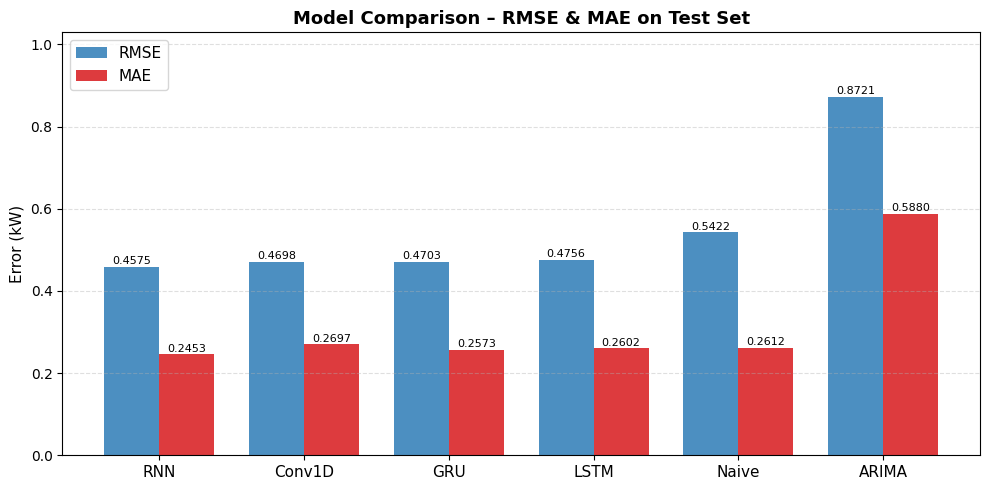

In [ ]:
# ── Figure 1: Bar chart of RMSE and MAE per model ────────────────────────────
model_names = list(summary.index)
rmse_vals   = summary['RMSE (kW)'].values
mae_vals    = summary['MAE (kW)'].values
x = np.arange(len(model_names))
width = 0.38

colors_rmse = '#2c7bb6'
colors_mae  = '#d7191c'

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, rmse_vals, width, label='RMSE', color=colors_rmse, alpha=0.85)
bars2 = ax.bar(x + width/2, mae_vals,  width, label='MAE',  color=colors_mae,  alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Error (kW)', fontsize=11)
ax.set_title('Model Comparison – RMSE & MAE on Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(rmse_vals) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()

The bar chart compares the performance of all models using RMSE (blue) and MAE (red) on the test set. Lower values indicate better performance.

From the chart, the RNN model clearly performs the best, achieving the lowest RMSE (0.4575) and MAE (0.2453). This shows that the RNN was the most effective at capturing short-term temporal patterns in the data.

The Conv1D, GRU, and LSTM models all perform similarly, with slightly higher error values than the RNN. Among these, Conv1D and GRU perform slightly better than LSTM, but none outperform the RNN. This means  that while these models are capable of learning patterns in the data, their additional complexity does not provide a significant advantage for this short-term forecasting task.

The Naive model performs worse than all neural network models but still achieves relatively low error.

Finally, the ARIMA model performs the worst by a large margin, with significantly higher RMSE and MAE compared to all other models. This highlights that ARIMA struggles with this dataset, likely due to its assumptions of linearity and stationarity, which do not hold well for minute-level electricity consumption data.

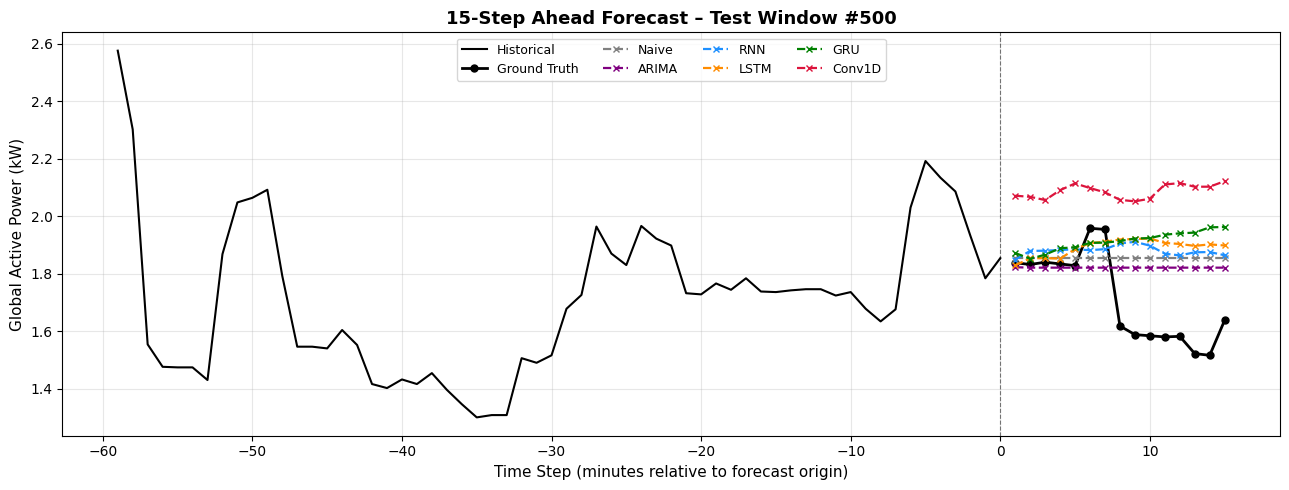

In [ ]:
# ── Figure 2: Forecast vs Ground Truth for a single test window ───────────────
WINDOW_IDX = 500   # pick any index in the test set

# Ground truth
gt = inverse_target(y_test[WINDOW_IDX])          # (15,)
steps = np.arange(1, HORIZON + 1)

# Historical context (last 60 minutes for readability)
history_raw = inverse_target(X_test[WINDOW_IDX, -60:, target_idx])
hist_steps  = np.arange(-59, 1)

model_colors = {
    'Naive':  'gray',
    'ARIMA':  'purple',
    'RNN':    'dodgerblue',
    'LSTM':   'darkorange',
    'GRU':    'green',
    'Conv1D': 'crimson',
}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hist_steps, history_raw, color='black', lw=1.5, label='Historical')
ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.plot(steps, gt, 'k-o', lw=2, markersize=5, label='Ground Truth')

for name, (_, _, preds) in results.items():
    # For ARIMA we only have N_EVAL predictions;
    # use test-set index directly for neural models
    if name == 'ARIMA':
        # find nearest evaluated window
        closest = np.argmin(np.abs(idxs - WINDOW_IDX))
        fc = inverse_target(preds[closest])
    elif name == 'Naive':
        fc = inverse_target(preds[WINDOW_IDX])
    else:
        fc = inverse_target(preds[WINDOW_IDX])
    ax.plot(steps, fc, linestyle='--', color=model_colors[name],
            lw=1.6, marker='x', markersize=5, label=name)

ax.set_xlabel('Time Step (minutes relative to forecast origin)', fontsize=11)
ax.set_ylabel('Global Active Power (kW)', fontsize=11)
ax.set_title(f'15-Step Ahead Forecast – Test Window #{WINDOW_IDX}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_comparison_window.png', dpi=150)
plt.show()

This plot shows a 15-step ahead forecast for a single test window, comparing each model’s predictions to the actual ground truth.

The black line on the left represents the historical data (past 120 minutes), while the black dots on the right represent the true future values. The dashed vertical line marks the point where forecasting begins.

From the graph, the RNN, GRU, and LSTM models produce predictions that are relatively close to the  truh, especially in the early steps. Among them, the RNN tracks the actual trend most closely, which is consistent with its lowest RMSE and MAE in the overall evaluation.

The Conv1D model tends to overestimate the values, consistently predicting higher than the actual data. This suggests that while it captures general trends, it struggles with accurately modeling the exact magnitude of changes.

The Naive model produces flat predictions, simply repeating the last observed value. While this works reasonably well for the first few steps, it fails to capture any downward trend in the actual data.

The ARIMA model produces constant predictions that are significantly lower than the other models, this means that it is unable to adapt to the local dynamics of this window. This aligns with its poor performance overall.

Overall when looking at the predictions and how the data is it is difficult to find a consistent pattern which shows in how the different models predicted the next 15 minutes.

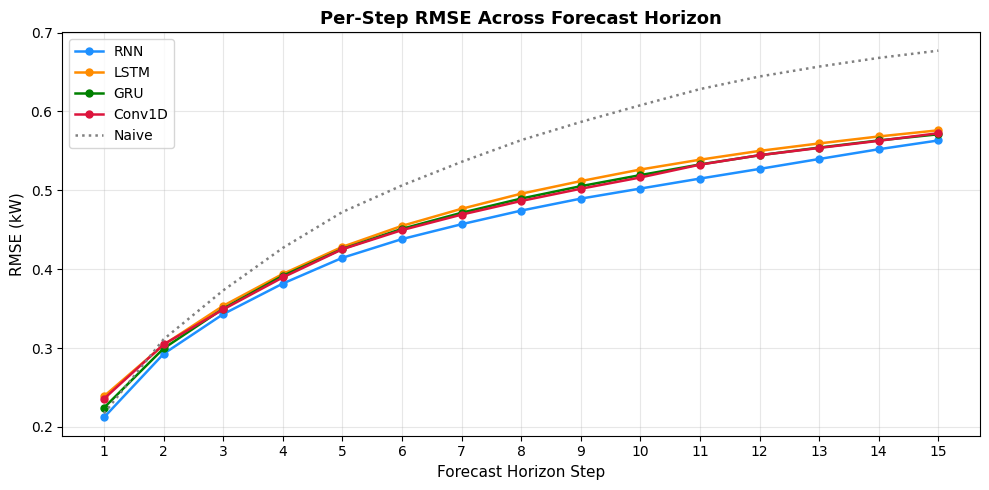

In [ ]:
# ── Figure 3: Per-step RMSE (for neural network models) ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

nn_models = ['RNN', 'LSTM', 'GRU', 'Conv1D']
for name in nn_models:
    _, _, preds = results[name]
    per_step = [
        np.sqrt(mean_squared_error(
            inverse_target(y_test[:, s]),
            inverse_target(preds[:, s])
        ))
        for s in range(HORIZON)
    ]
    ax.plot(range(1, HORIZON + 1), per_step,
            marker='o', lw=1.8, markersize=5,
            color=model_colors[name], label=name)

# Naive per-step
naive_per_step = [
    np.sqrt(mean_squared_error(
        inverse_target(y_test[:, s]),
        inverse_target(naive_preds[:, s])
    ))
    for s in range(HORIZON)
]
ax.plot(range(1, HORIZON + 1), naive_per_step,
        linestyle=':', lw=1.8, color='gray', label='Naive')

ax.set_xlabel('Forecast Horizon Step', fontsize=11)
ax.set_ylabel('RMSE (kW)', fontsize=11)
ax.set_title('Per-Step RMSE Across Forecast Horizon', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, HORIZON + 1))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('per_step_rmse.png', dpi=150)
plt.show()

From the graph, all models show an increasing RMSE as the forecast horizon increases. This is expected because predictions become more uncertain the further into the future the model forecasts.

The RNN consistently has the lowest RMSE at every step, showing that it maintains the best accuracy throughout the entire forecast horizon. This reinforces earlier results showing that the RNN is the most reliable model for this task.

The LSTM, GRU, and Conv1D models follow a very similar trend, with slightly higher RMSE than the RNN at each step. This suggests that while these models can learn temporal patterns, they are  less precise in maintaining accuracy as predictions extend further into the future.

The Naive model performs significantly worse, with RMSE increasing much more rapidly. This shows that simply repeating the last observed value becomes less effective as the forecast horizon increases, especially when the underlying data begins to change.

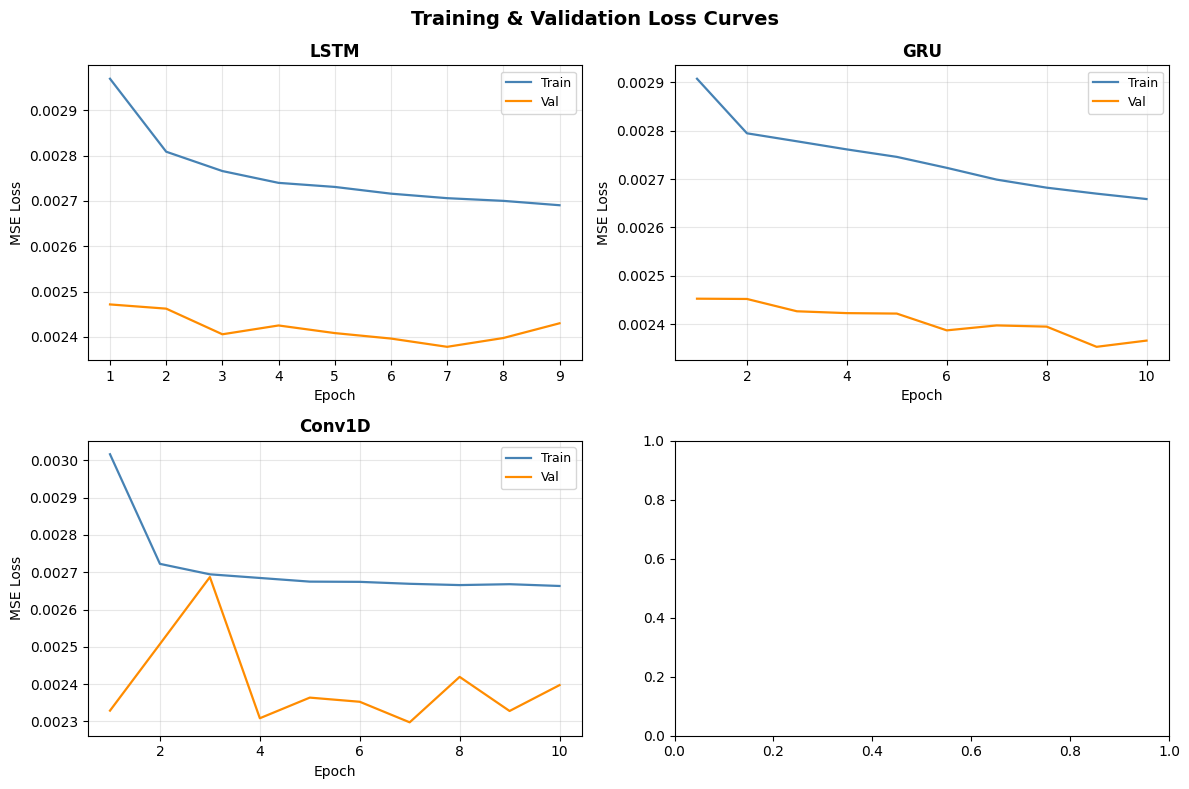

In [ ]:
# ── Figure 4: Training curves for neural models ───────────────────────────────
loss_curves = {
    'RNN':    (rnn_train_losses,  rnn_val_losses),
    'LSTM':   (lstm_tr, lstm_vl),
    'GRU':    (gru_tr,  gru_vl),
    'Conv1D': (conv_tr, conv_vl),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for ax, (name, (tr, vl)) in zip(axes.flatten(), loss_curves.items()):
    epochs = range(1, len(tr) + 1)
    ax.plot(epochs, tr, label='Train', color='steelblue', lw=1.6)
    ax.plot(epochs, vl, label='Val',   color='darkorange', lw=1.6)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Training & Validation Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

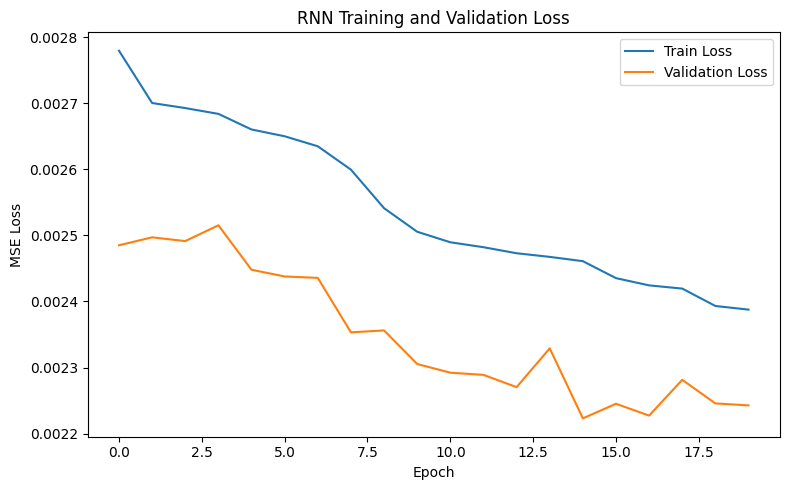


For all models, the training loss steadily decreases over time, which indicates that each model is successfully learning patterns from the training data.

The validation loss remains relatively stable and slightly decreases, which suggests that the models are generalizing well to unseen data and are not significantly overfitting. There is no large gap between training and validation loss, which is a sign of balanced learning.

For the LSTM and GRU models, the validation loss gradually improves and then stabilizes. This indicates that additional training beyond a certain point provides diminishing returns, which is why early stopping is effective. This was seen throughout the project as at first I had many epochs but the values were beginning to stay the same and it was learning less as I went a long but taking a lot time.

The Conv1D model shows slightly more fluctuation in validation loss, but it still maintains a similar overall range. This suggests that while it learns useful patterns, it is slightly less stable compared to the recurrent models.

## Summary of Findings
Dataset & Preprocessing
- The dataset contained 4 years of data with 2,049,280 rows
- The missing values were handled through linear interpolation as I beleived it was best suited for this dataset rather than taking the previous value or filling it it in with the median or most reoccurent value.


# Model performance
| Model  |       RMSE |        MAE |
| ------ | ---------: | ---------: |
| RNN    | **0.4575** | **0.2453** |
| Conv1D |     0.4698 |     0.2697 |
| GRU    |     0.4703 |     0.2573 |
| LSTM   |     0.4756 |     0.2602 |
| Naive  |     0.5422 |     0.2612 |
| ARIMA  |     0.8721 |     0.5880 |

Out of all of the models the RNN achieved the best performance with the lowest RMSE and MAE. This means that this model was the most effective at capturing the temporal patterns in the data and giving short term forecasts.

The reason the RNN performed best is due to the nature of the problem. Since we are using the previous 120 minutes to predict the next 15 minutes, the task mainly depends on short-term dependencies. RNNs are well-suited for sequential data where order matters, as they process information step-by-step and retain recent patterns. A similar use case would be short-term stock price forecasting, where recent movements are most important.RNNs maintain a hidden state that carries information from previous time steps, allowing them to learn patterns across the sequence.


When looking at LSTMs they are designed for long term dependencies. Although it can also be used for forecasting since we only used the previous 120 minutes to predict the next 15 it did not perform as well. However if we were to look at all of the history or weekly trends the results would probably have been different. Additionally they are typically used where RNNS struggle like in long time tasks.

The GRU model, which is a simplified version of LSTM, performed slightly better than LSTM. This is expected because GRUs are designed to capture medium-length dependencies while being more efficient and easier to train. However, like LSTM, it did not outperform the RNN because long-term memory was not critical for this task.

For Conv1D these are best for detecting local patterns in time series data using convolutional filters. It is often used for signal processing or detecting short bursts of activity in sensor data. It was able to capture short term trends reasonably well which is why is performed well competitively. However it does not model sequential dependencies over time like RNNS which is why it did not achieve the best performance.

The Naive model which repeats the last observed value gave a decent baseline. This means that the dataset has a strong short term autocorrelation which means recent values are good predicotors for future values.

The ARIMA model performed the wost. This is because ARIMA is best for linear and stationary relationships. However electricity consumption is not linear and highly variable at the minute level. Additionally tere had to be much changing of the model for ARIMA as for it to take in more of the data it was taking up much RAM limiting its effectiveness. Additionally,  ARIMA relies on differencing to make the data stationary, which may not fully capture the complex patterns in high-frequency electricity data.